# Анализ алгоритмов

In [2]:
import time

import geopandas as gpd
import osmnx as ox
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genesis.metrics import *
# from genesis.core import BestPointsBase, StateBase
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar, timing
from genesis.swiss_knife import CMAP_GrGldRd
# from genesis.best_points import 

# Загрузка исходных данных и разбиение по районам

In [3]:
map_path = 'D:/QGIS/_Красноярск ДИССЕРТАЦИЯ'
# map_path = 'G:/QGIS/_Красноярск ДИССЕРТАЦИЯ'

# ГДС
G = ox.load_graphml(map_path+"/fire_data/rng.ml")
print(G.number_of_nodes(), G.number_of_edges())

# районы
districts = gpd.read_file(map_path+"/data/districts.gpkg", layer='Районы')
districts = districts.set_index(districts['name'])
# districts.plot(column='name', legend=True)
print('Районы Красноярска:', list(districts.index))

# здания
buildings = gpd.read_file(map_path+"/data/bld.gpkg", layer='здания')
buildings = buildings[['osmid', 'building', 'kfpo_spros', 'geometry']]   # 'name', 'amenity', 
buildings = buildings.set_index('osmid')
print('Всего зданий в Красноярске:', len(buildings))

31293 77344
Районы Красноярска: ['Железнодорожный район', 'Кировский район', 'Ленинский район', 'Октябрьский район', 'Свердловский район', 'Советский район', 'Центральный район']
Всего зданий в Красноярске: 58094


Установка скоростей следования для ГДС

In [4]:
from graphs.speeds import kmh_to_mm, set_graph_travel_times

speeds = [53, 40, 28.1, 17.3, 5.4]
speeds = [kmh_to_mm(s) for s in speeds]

set_graph_travel_times(G, speeds)

d:\Git\genesis\work\genesis\graphs\speeds.py:96: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


Приведение к единой системе координат

In [5]:
print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


In [6]:
G = ox.project_graph(G)
districts = ox.project_gdf(districts)
buildings = ox.project_gdf(buildings)

print('Проверка СК:', end=' ')
if not G.graph['crs'] == districts.crs == buildings.crs:
    raise ValueError('CRS G, districts и buildings различны!')
else:
    print('CRS совпадают.')

Проверка СК: CRS совпадают.


Дополнение зданий сведениями о ближайших узлах ГДС

In [7]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
buildings = buildings.sjoin_nearest(g_nodes[['geometry']], max_distance=100)
buildings.rename(columns={'index_right': 'node'}, inplace=True)

Разбор графа и зданий на наборы для районов

In [8]:
# g_nodes = ox.graph_to_gdfs(G, edges=False)

scopes = {}
for i, district in districts.iterrows():
    poly = district['geometry']
    print(f'{i}: ', end='')

    # Граф
    g_nodes_in = g_nodes.loc[g_nodes.intersects(poly.buffer(1000))]
    g = nx.subgraph(G, g_nodes_in.index)
    # оставляем только больший сильносвязный компонент:
    # g = max(nx.strongly_connected_components(g), key=len)
    g = nx.subgraph(g, max(nx.strongly_connected_components(g), key=len))
    print(g.number_of_nodes(), g.number_of_edges(), end=' ')

    # Здания
    b = buildings.loc[buildings.intersects(poly)]
    print(len(b))

    scopes[i] = [poly, g, b]

Железнодорожный район: 3515 8411 2898
Кировский район: 5100 12939 3382
Ленинский район: 5953 15022 4812
Октябрьский район: 7008 17201 11798
Свердловский район: 5490 13597 15159
Советский район: 9377 22942 8101
Центральный район: 5641 13763 6440


In [ ]:
# def plot_g(name, g, b, poly, ax):
#     ax.set_title(name)
#     ax.set_axis_off()
#     ax.set_facecolor('white')
#     ox.plot_graph(g, node_size=0, edge_linewidth=0.2, ax=ax, show=False)
#     b.plot(ax=ax)
#     poly.plot(color='none', edgecolor='r', linewidth=1, ax=ax)


# fig, axs = plt.subplots(3,3, tight_layout=True, figsize=(12,12), dpi=300)
# x,y = 0,0
# for district in districts.index:
#     print(f'{district} [{y,x}]: ', end='')
#     g = scopes[district][1]
#     b = scopes[district][2]
#     plot_g(district, g, b, districts.loc[[district]], axs[y,x])
#     x += 1
#     if x >= 3:
#         x = 0
#         y += 1
#     print('ok')

# ax=axs[2,1]
# ax.set_title('г. Красноярск')
# ax.set_axis_off()
# ax.set_facecolor('white')
# districts.plot(column='name', ax=ax, legend=True, legend_kwds={'fontsize': 6, 'markerscale':0.5})

# plt.delaxes(axs[2,2])

# fig.tight_layout()

# Вычислительные эксперименты

## BLP

In [9]:
from fire_units.metrics import Demand
from genesis.best_points import BestNodesFull


district = 'Железнодорожный район'
poly = scopes[district][0]
g    = scopes[district][1]
b    = scopes[district][2]
nodes = ox.graph_to_gdfs(g, edges=False)
area_nodes = nodes.within(poly)
nodes_list=set(nodes[area_nodes].index)

print('Узлов', sum(area_nodes))

# функция метрики спроса
metric_demand = Demand(b, buildings_demand_field='kfpo_spros')

Узлов 1861


In [10]:
# Полный перебор - эталонное значение
pb = Progressbar(sum(area_nodes), bins=40)
full = timing(BestNodesFull(FirstArrivalUnitState(), metric_demand, node_calc_end_function=pb), return_time=True)

best_nodes, best_metric, time_spent = full(env=g, area=area_nodes, nodes_list=nodes_list)
etalon_node, etalon_metric, etalon_time = best_nodes[0], best_metric, time_spent

etalon_node, etalon_metric, etalon_time

|########################################| 100.0%
ВРЕМЯ: 352.29 сек


(345759063, 0.00111746411505084, 352.29)

In [11]:
import random
from genesis.best_points import BestNodeHillClimbing

bnhc = BestNodeHillClimbing(FirstArrivalUnitState(), metric_demand)

bn_list = []
bn_metrics = []
i=1

ts = time.time()
while time.time() - ts < etalon_time:
    start_node = random.choice(list(nodes_list))
    best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=start_node)
    bn_list.append(best_node)
    bn_metrics.append(best_metric)
    print(i, ts, etalon_time, end='\r')
    i+=1

tf = time.time()
td = round(tf-ts, 2)
print(f'ВРЕМЯ: {td} сек')

correct_results = bn_list.count(etalon_node)
print(f'КОРРЕКТНОСТЬ: {correct_results} из {len(bn_list)}')
print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {td/len(bn_list)} сек')

ВРЕМЯ: 352.87 сек
КОРРЕКТНОСТЬ: 6 из 63
Время одного расчета: 5.601111111111111 сек


In [12]:
from genesis.best_points import BestNodeMonkey


class EventFunc:
    def __init__(self):
        self.history = []
        self.best_metric = 0
    
    def __call__(self, **kwargs):
        global_jump_number = kwargs['global_jump_number']
        local_jump_number = kwargs.get('local_jump_number', 0)
        print("Глобальный прыжок:", global_jump_number, ", Локальный прыжок:", local_jump_number, '  ', end='\r')

bnmsa = BestNodeMonkey(FirstArrivalUnitState(), metric_demand, 
                               global_jumps_count=3,
                               local_jumps_count=3,
                               all_neighbors=True,
                               after_global_jump_function=EventFunc(),
                               after_local_jump_function=EventFunc(),
                               )

bn_list = []
bn_metrics = []
i=1

ts = time.time()
while time.time() - ts < etalon_time:
    best_node, best_metric = bnmsa(env=g, area=area_nodes)
    bn_list.append(best_node)
    bn_metrics.append(best_metric)
    print(i, ts, etalon_time) #, end='\r')
    i+=1

tf = time.time()
td = round(tf-ts, 2)
print(f'ВРЕМЯ: {td} сек')

correct_results = bn_list.count(etalon_node)
print(f'КОРРЕКТНОСТЬ: {correct_results} из {len(bn_list)}')
print(f'ВРЕМЯ ОДНОГО РАСЧЕТА: {td/len(bn_list)} сек')


best_node, best_metric

ВРЕМЯ: 396.0 сек089 352.29альный прыжок: 2   
КОРРЕКТНОСТЬ: 4 из 5
Время одного расчета: 79.2 сек


(345759063, 0.00111746411505084)

In [17]:
from genesis.best_points import BestNodesHalfDiameter

bnhd = BestNodesHalfDiameter(FirstArrivalUnitState(), metric_demand)

ts = time.time()

start_node = bnhd(env=g, area=area_nodes)
best_node, best_metric = bnhc(env=g, area=area_nodes, start_node=start_node)
bn_list.append(best_node)
bn_metrics.append(best_metric)

tf = time.time()
td = round(tf-ts, 2)

print(f'ВРЕМЯ: {td} сек')

correct_results = best_metric/etalon_metric
print(f'КОРРЕКТНОСТЬ: {correct_results}')
print(f'Время одного расчета: {td} сек')

ВРЕМЯ: 3.36 сек
КОРРЕКТНОСТЬ: 0.9588926144997069
Время одного расчета: 3.36 сек


# Черновики

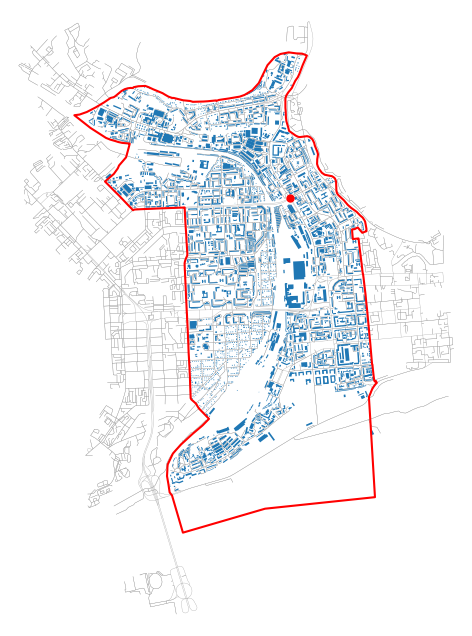

In [52]:
# Печать карты
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

    return 1, 2

d = timing(plot_scope_result(g, districts.loc[[district]], best_nodes, b))
d

In [48]:
state, _ = FirstArrivalUnitState()(g, points={best_nodes[0]:'best'})
area = area_nodes
if isinstance(state, pd.Series):
    state_c = state.loc[area]
else:
    state_c = [x for x in state if x in area]

# Расчет метрики по спросу
merged_df = pd.merge(b,
                    state_c,
                    left_on='node',
                    right_index=True)

merged_df['demand_val'] = merged_df['node'] / merged_df['times']

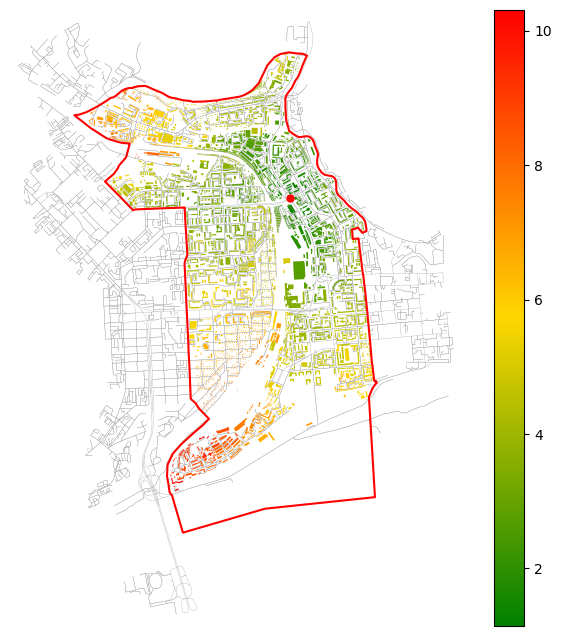

In [49]:
def plot_scope_result(g:nx.MultiDiGraph,
                      district:gpd.GeoDataFrame,
                      point:list,
                      buildings:pd.DataFrame,
                      ax=None):
    nodes = ox.graph_to_gdfs(g, edges=False)
    if ax is None:
        fig, ax = ox.plot_graph(g, edge_linewidth=0.2, node_size=0, show=False, bgcolor='white')
    district.boundary.plot(ax=ax, color='r')
    buildings.plot(ax=ax, column='times', cmap=CMAP_GrGldRd, legend=True)
    nodes.loc[point].plot(ax=ax, markersize=25, color='red')

plot_scope_result(g, districts.loc[[district]], best_nodes, merged_df)